In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# para matching ΔR
from math import sqrt


In [25]:
# Define la ruta base para todos los archivos CSV
ruta_base = r"C:\Users\Usuario\Documents\UD\Parcial minería 2\Mineria_de_Datos-1\Parcial Final\Events\Run_198272\CSV\Event_272621358"

# Importación de los archivos CSV usando la ruta completa
tracks = pd.read_csv(f"{ruta_base}/Tracks_V3.csv")
gsf = pd.read_csv(f"{ruta_base}/GsfElectrons_V2.csv")
trkmu = pd.read_csv(f"{ruta_base}/TrackerMuons_V1.csv")
standmu = pd.read_csv(f"{ruta_base}/StandaloneMuons_V2.csv")
globmu = pd.read_csv(f"{ruta_base}/GlobalMuons_V1.csv")
taus = pd.read_csv(f"{ruta_base}/PFTaus_V1.csv")

print("¡Archivos cargados exitosamente!")

¡Archivos cargados exitosamente!


In [26]:
muons = pd.concat([trkmu, standmu, globmu], ignore_index=True)

# Eliminar duplicados por (pt, eta, phi)
muons = muons.drop_duplicates(subset=["pt", "eta", "phi"])


In [27]:
def deltaR(eta1, phi1, eta2, phi2):
    dphi = abs(phi1 - phi2)
    if dphi > np.pi:
        dphi = 2*np.pi - dphi
    deta = eta1 - eta2
    return sqrt(deta*deta + dphi*dphi)

def match_tracks_to_obj(tracks, objs, maxDR=0.03):
    matches = []
    for idx, trk in tracks.iterrows():
        best = None
        bestDR = 999
        for j, obj in objs.iterrows():
            dr = deltaR(trk["eta"], trk["phi"], obj["eta"], obj["phi"])
            if dr < bestDR and dr < maxDR:
                best = obj
                bestDR = dr
        if best is not None:
            matches.append((idx, best))
    return matches


In [28]:
m_muon  = match_tracks_to_obj(tracks, muons)
m_el    = match_tracks_to_obj(tracks, gsf)
m_tau   = match_tracks_to_obj(tracks, taus)


In [29]:
labels = pd.Series(["hadron"] * len(tracks), index=tracks.index)

# Muones
for idx, obj in m_muon:
    if obj["charge"] > 0:
        labels[idx] = "muon+"
    else:
        labels[idx] = "muon-"

# Electrones
for idx, obj in m_el:
    if obj["charge"] > 0:
        labels[idx] = "positron+"
    else:
        labels[idx] = "electron-"

# Taus
for idx, obj in m_tau:
    if obj["charge"] > 0:
        labels[idx] = "tau+"
    else:
        labels[idx] = "tau-"

# Separar hadrones
for i in labels.index:
    if "hadron" in labels[i]:
        if tracks.loc[i]["charge"] > 0:
            labels[i] = "hadron+"
        else:
            labels[i] = "hadron-"


In [30]:
X = tracks[["pt", "eta", "phi", "chi2", "ndof"]].copy()
y = labels.copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [43]:
%%time

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Configuración paralelizada
clf = OneVsRestClassifier(
    LogisticRegression(
        multi_class="multinomial",
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ),
    n_jobs=-1   # paralelización
)

print("Entrenando modelo...")
_ = clf.fit(X_train, y_train)  # evita que el modelo se imprima
print("Entrenamiento completado.")


Entrenando modelo...
Entrenamiento completado.
CPU times: total: 31.2 ms
Wall time: 13 ms


In [50]:
# Mostrar las clases reales del LabelEncoder
print("Clases del encoder:")
print(le.classes_)


Clases del encoder:
['hadron+' 'hadron-' 'tau+' 'tau-']


In [51]:
from sklearn.metrics import classification_report

print("=== Reporte de Clasificación ===\n")
print("Clases detectadas:", le.classes_, "\n")

reporte = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    digits=2
)

print(reporte)


=== Reporte de Clasificación ===

Clases detectadas: ['hadron+' 'hadron-' 'tau+' 'tau-'] 

              precision    recall  f1-score   support

     hadron+       0.50      0.78      0.61         9
     hadron-       0.25      0.12      0.17         8
        tau+       0.00      0.00      0.00         2
        tau-       0.00      0.00      0.00         3

    accuracy                           0.36        22
   macro avg       0.19      0.23      0.19        22
weighted avg       0.30      0.36      0.31        22



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

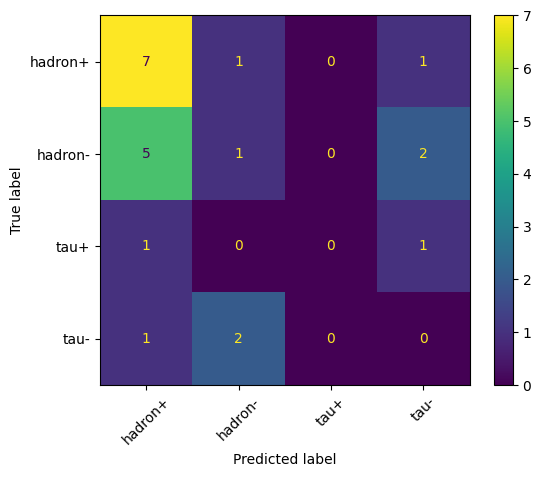

In [38]:
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_encoded))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.inverse_transform(np.unique(y_encoded))
)
disp.plot(xticks_rotation=45)
plt.show()


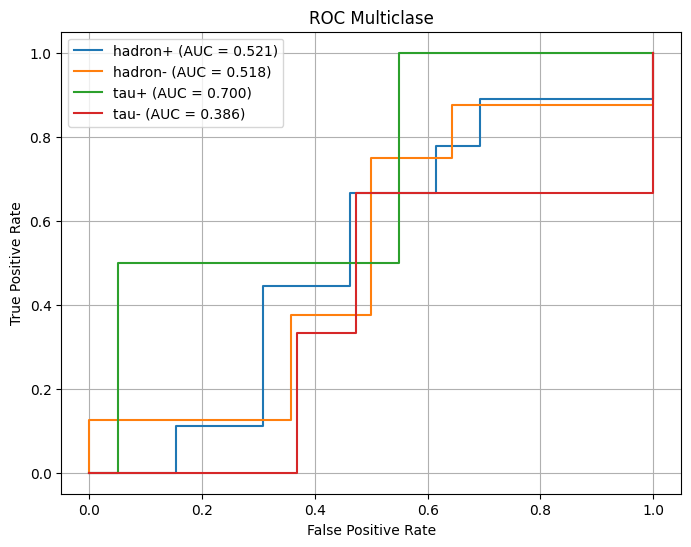

In [39]:
y_bin = label_binarize(y_test, classes=np.unique(y_encoded))
y_score = clf.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i, class_name in enumerate(le.inverse_transform(np.unique(y_encoded))):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Multiclase")
plt.legend()
plt.grid(True)
plt.show()


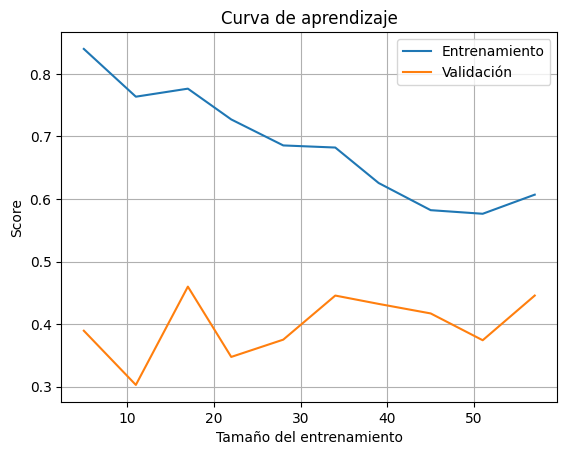

In [40]:
train_sizes, train_scores, test_scores = learning_curve(
    clf, X, y_encoded, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, test_mean, label="Validación")
plt.xlabel("Tamaño del entrenamiento")
plt.ylabel("Score")
plt.title("Curva de aprendizaje")
plt.legend()
plt.grid(True)
plt.show()


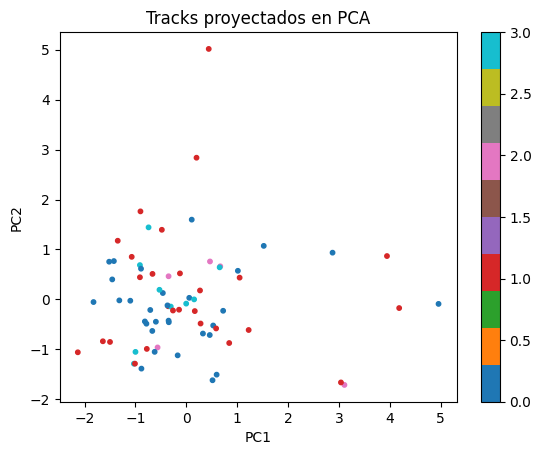

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.fit_transform(X))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded, cmap="tab10", s=10)
plt.title("Tracks proyectados en PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()
